In [20]:
import pandas as pd
import datetime
import numpy as np
import matplotlib.pyplot as plt
import astral
from astral import sun
from pandas.tseries.holiday import USFederalHolidayCalendar

In [2]:
scraped = pd.read_csv('ecocounter_bike_traffic_data.csv')
scraped["Date"] = scraped["Date"].apply(lambda x: datetime.datetime.strptime(x, '%Y-%m-%d'))
scraped = scraped.set_index("Date")
scraped

,Count
Date,
2024-01-01,307
2024-01-02,360
2024-01-03,475
2024-01-04,580
2024-01-05,646
...,...
2025-12-27,231
2025-12-28,221
2025-12-29,295


# Import and merge direct download count data

In [3]:
bike_direct = pd.read_csv('bike.csv')
bike_direct["DateTime"] = bike_direct["DateTime"].apply(lambda x: datetime.datetime.strptime(x, '%m/%d/%Y %H:%M'))
bike_direct = bike_direct.rename(columns = {'DateTime':'Date',
                                           '<tspan>IN (In)</tspan>':'In (Bike)',
                                           '<tspan>OUT (Out)</tspan>':'Out (Bike)'})
bike_direct["Total (Bike)"] = bike_direct["In (Bike)"] + bike_direct["Out (Bike)"]
bike_direct = bike_direct.set_index("Date")

In [4]:
scooter_direct = pd.read_csv('scooter.csv')
scooter_direct["DateTime"] = scooter_direct["DateTime"].apply(lambda x: datetime.datetime.strptime(x, '%m/%d/%Y %H:%M'))
scooter_direct = scooter_direct.rename(columns = {'DateTime':'Date',
                                           '<tspan>IN (In)</tspan>':'In (Scooter)',
                                           '<tspan>OUT (Out)</tspan>':'Out (Scooter)'})
scooter_direct["Total (Scooter)"] = scooter_direct["In (Scooter)"] + scooter_direct["Out (Scooter)"]
scooter_direct = scooter_direct.set_index("Date")

In [5]:
counts_direct = pd.merge(bike_direct,
                         scooter_direct,
                         how="outer",
                         left_index=True,
                         right_index=True
                        )
counts_direct["In"] = counts_direct["In (Bike)"] + counts_direct["In (Scooter)"]
counts_direct["Out"] = counts_direct["Out (Bike)"] + counts_direct["Out (Scooter)"]
counts_direct["Total"] = counts_direct["Total (Bike)"] + counts_direct["Total (Scooter)"]

counts_direct_weekly = counts_direct.resample("W", label='left').sum()

In [6]:
display(counts_direct, counts_direct_weekly)

,In (Bike),Out (Bike),Total (Bike),In (Scooter),Out (Scooter),Total (Scooter),In,Out,Total
Date,,,,,,,,,
2023-05-25,885,959,1844,141,121,262,1026,1080,2106
2023-05-26,900,936,1836,138,132,270,1038,1068,2106
2023-05-27,545,618,1163,80,85,165,625,703,1328
2023-05-28,439,448,887,59,81,140,498,529,1027
2023-05-29,472,491,963,84,87,171,556,578,1134
...,...,...,...,...,...,...,...,...,...
2026-02-27,795,855,1650,340,302,642,1135,1157,2292
2026-02-28,547,622,1169,306,255,561,853,877,1730
2026-03-01,426,458,884,211,205,416,637,663,1300


,In (Bike),Out (Bike),Total (Bike),In (Scooter),Out (Scooter),Total (Scooter),In,Out,Total
Date,,,,,,,,,
2023-05-21,2769,2961,5730,418,419,837,3187,3380,6567
2023-05-28,6269,6286,12555,919,812,1731,7188,7098,14286
2023-06-04,6109,6435,12544,963,776,1739,7072,7211,14283
2023-06-11,4148,4740,8888,649,630,1279,4797,5370,10167
2023-06-18,2331,2674,5005,290,339,629,2621,3013,5634
...,...,...,...,...,...,...,...,...,...
2026-02-01,4976,4920,9896,1994,1605,3599,6970,6525,13495
2026-02-08,3940,3983,7923,1663,1269,2932,5603,5252,10855
2026-02-15,3133,3168,6301,1409,1100,2509,4542,4268,8810


Our scraped counts for both bike and scooter match the direct download data, so that's good

In [7]:
pd.merge(scraped, counts_direct, how="left", left_index=True, right_index=True)

,Count,In (Bike),Out (Bike),Total (Bike),In (Scooter),Out (Scooter),Total (Scooter),In,Out,Total
Date,,,,,,,,,,
2024-01-01,307,127,111,238,38,31,69,165,142,307
2024-01-02,360,128,158,286,25,49,74,153,207,360
2024-01-03,475,196,207,403,33,39,72,229,246,475
2024-01-04,580,232,244,476,56,48,104,288,292,580
2024-01-05,646,260,292,552,53,41,94,313,333,646
...,...,...,...,...,...,...,...,...,...,...
2025-12-27,231,66,93,159,31,41,72,97,134,231
2025-12-28,221,69,98,167,23,31,54,92,129,221
2025-12-29,295,88,140,228,26,41,67,114,181,295


### Merging day of week

In [8]:
counts_direct["Day of Week"] = counts_direct.index.day_name()

### Merging holidays

In [25]:
USFederalHolidayCalendar().holidays()

DatetimeIndex(['1970-01-01', '1970-02-16', '1970-05-25', '1970-07-03',
               '1970-09-07', '1970-10-12', '1970-11-11', '1970-11-26',
               '1970-12-25', '1971-01-01',
               ...
               '2200-01-20', '2200-02-17', '2200-05-26', '2200-06-19',
               '2200-07-04', '2200-09-01', '2200-10-13', '2200-11-11',
               '2200-11-27', '2200-12-25'],
              dtype='datetime64[us]', length=2474, freq=None)

### Merging hours of daylight

<Axes: xlabel='Date'>

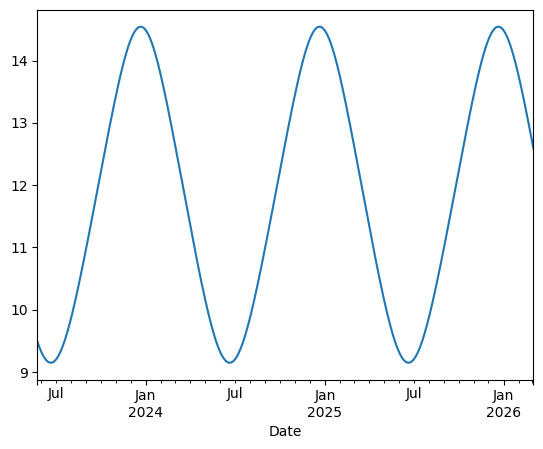

In [11]:
def find_hours_daylight(datetime):
    # Create observer object at Davis bike counter location
    observer = astral.Observer(latitude=38.544406,
                           longitude=-121.74263)
    timedelta = astral.sun.sunrise(observer, datetime) - astral.sun.sunset(observer, datetime)
    seconds = timedelta.total_seconds()
    hours = seconds / 3600
    return hours

hours_of_daylight = []
for index in counts_direct.index:
    hours_of_daylight.append(find_hours_daylight(index))
hours_of_daylight

counts_direct["Hours of daylight"] = hours_of_daylight

counts_direct["Hours of daylight"].plot()

### Merging Temperature

In [12]:
temperature = pd.read_csv("temperature.csv")
temperature = temperature[["DATE", "PRCP", "TMAX", "TMIN"]]
temperature = temperature.rename(columns={'DATE': 'Date',
                                          'PRCP': 'Precipitation',
                                          'TMAX': 'Max temperature',
                                          'TMIN': 'Min temperature'
                                         })
temperature["Date"] = temperature["Date"].apply(lambda x: datetime.datetime.strptime(x, '%Y-%m-%d'))
temperature = temperature.set_index('Date')

temperature_weekly = temperature.resample("W", label="left").agg(
    Precipitation_sum=('Precipitation', 'sum'),
    Max_temperature_max=('Max temperature', 'max'),
    Max_temperature_mean=('Max temperature', 'mean'),
    Min_temperature_min=('Min temperature', 'min'),
    Min_temperature_mean=('Min temperature', 'mean')
)
temperature_weekly = temperature_weekly.rename(columns={
    'Precipitation_sum': 'Precipitation (sum)',
    'Max_temperature_max':'Max temperature (max)',
    'Max_temperature_mean':'Max temperature (mean)',
    'Min_temperature_min':'Min temperature (min)',
    'Min_temperature_mean':'Min temperature (mean)'
})

In [13]:
display(temperature, temperature_weekly)

,Precipitation,Max temperature,Min temperature
Date,,,
2023-05-24,0.00,77.0,52.0
2023-05-25,0.00,75.0,50.0
2023-05-26,0.00,75.0,53.0
2023-05-27,0.00,78.0,52.0
2023-05-28,0.00,79.0,55.0
...,...,...,...
2026-02-17,0.75,52.0,43.0
2026-02-18,0.22,50.0,33.0
2026-02-19,0.62,54.0,34.0


,Precipitation (sum),Max temperature (max),Max temperature (mean),Min temperature (min),Min temperature (mean)
Date,,,,,
2023-05-21,0.00,79.0,76.800000,50.0,52.400000
2023-05-28,0.00,93.0,82.857143,49.0,52.000000
2023-06-04,0.00,95.0,83.428571,50.0,54.714286
2023-06-11,0.00,95.0,87.571429,55.0,56.285714
2023-06-18,0.00,87.0,82.428571,47.0,51.000000
...,...,...,...,...,...
2026-01-18,0.03,67.0,58.000000,34.0,39.571429
2026-01-25,0.07,64.0,60.142857,35.0,37.285714
2026-02-01,0.00,74.0,70.750000,38.0,41.000000


In [14]:
merged_data_direct = pd.merge(counts_direct,
                              temperature,
                              how='inner',
                              left_index=True,
                              right_index=True
                             )
merged_data_direct_weekly = pd.merge(counts_direct_weekly,
                                     temperature_weekly,
                                     how='inner',
                                     left_index=True,
                                     right_index=True
                                    )

In [15]:
display(merged_data_direct, merged_data_direct_weekly)

,In (Bike),Out (Bike),Total (Bike),In (Scooter),Out (Scooter),Total (Scooter),In,Out,Total,Day of Week,Hours of daylight,Precipitation,Max temperature,Min temperature
Date,,,,,,,,,,,,,,
2023-05-25,885,959,1844,141,121,262,1026,1080,2106,Thursday,9.484208,0.00,75.0,50.0
2023-05-26,900,936,1836,138,132,270,1038,1068,2106,Friday,9.461249,0.00,75.0,53.0
2023-05-27,545,618,1163,80,85,165,625,703,1328,Saturday,9.439000,0.00,78.0,52.0
2023-05-28,439,448,887,59,81,140,498,529,1027,Sunday,9.417477,0.00,79.0,55.0
2023-05-29,472,491,963,84,87,171,556,578,1134,Monday,9.396695,0.00,80.0,52.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-17,361,319,680,155,131,286,516,450,966,Tuesday,13.152480,0.75,52.0,43.0
2026-02-18,625,531,1156,247,154,401,872,685,1557,Wednesday,13.113098,0.22,50.0,33.0
2026-02-19,582,603,1185,254,169,423,836,772,1608,Thursday,13.073505,0.62,54.0,34.0


,In (Bike),Out (Bike),Total (Bike),In (Scooter),Out (Scooter),Total (Scooter),In,Out,Total,Precipitation (sum),Max temperature (max),Max temperature (mean),Min temperature (min),Min temperature (mean)
Date,,,,,,,,,,,,,,
2023-05-21,2769,2961,5730,418,419,837,3187,3380,6567,0.00,79.0,76.800000,50.0,52.400000
2023-05-28,6269,6286,12555,919,812,1731,7188,7098,14286,0.00,93.0,82.857143,49.0,52.000000
2023-06-04,6109,6435,12544,963,776,1739,7072,7211,14283,0.00,95.0,83.428571,50.0,54.714286
2023-06-11,4148,4740,8888,649,630,1279,4797,5370,10167,0.00,95.0,87.571429,55.0,56.285714
2023-06-18,2331,2674,5005,290,339,629,2621,3013,5634,0.00,87.0,82.428571,47.0,51.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-18,4134,4015,8149,1816,1362,3178,5950,5377,11327,0.03,67.0,58.000000,34.0,39.571429
2026-01-25,4758,4652,9410,1988,1464,3452,6746,6116,12862,0.07,64.0,60.142857,35.0,37.285714
2026-02-01,4976,4920,9896,1994,1605,3599,6970,6525,13495,0.00,74.0,70.750000,38.0,41.000000


Filter down to dates in 2024 and 2025 because we have full year of data--do note that for our weekly data, the date listed is the first day of that week. The first week available is only 1/7/2024, and we could manually add the week of 12/31/2023 if we want? We also have the week of 12/28/2025 even though some of the later days of that week spills over into 2026.

In [16]:
dateMask = (merged_data_direct.index >= datetime.datetime(2024, 1, 1)) & (merged_data_direct.index <= datetime.datetime(2025, 12, 31))
dateMask_weekly = (merged_data_direct_weekly.index >= datetime.datetime(2024, 1, 1)) & (merged_data_direct_weekly.index <= datetime.datetime(2025, 12, 31))

merged_data_direct = merged_data_direct[dateMask]
merged_data_direct_weekly = merged_data_direct_weekly[dateMask_weekly]

In [17]:
display(merged_data_direct, merged_data_direct_weekly)

,In (Bike),Out (Bike),Total (Bike),In (Scooter),Out (Scooter),Total (Scooter),In,Out,Total,Day of Week,Hours of daylight,Precipitation,Max temperature,Min temperature
Date,,,,,,,,,,,,,,
2024-01-01,127,111,238,38,31,69,165,142,307,Monday,14.489649,0.00,60.0,41.0
2024-01-02,128,158,286,25,49,74,153,207,360,Tuesday,14.478673,0.00,64.0,44.0
2024-01-03,196,207,403,33,39,72,229,246,475,Wednesday,14.466712,0.37,55.0,42.0
2024-01-04,232,244,476,56,48,104,288,292,580,Thursday,14.453779,0.01,61.0,36.0
2024-01-05,260,292,552,53,41,94,313,333,646,Friday,14.439885,0.00,63.0,39.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-27,66,93,159,31,41,72,97,134,231,Saturday,14.526470,0.09,60.0,38.0
2025-12-28,69,98,167,23,31,54,92,129,221,Sunday,14.520021,0.00,54.0,38.0
2025-12-29,88,140,228,26,41,67,114,181,295,Monday,14.512548,0.00,56.0,34.0


,In (Bike),Out (Bike),Total (Bike),In (Scooter),Out (Scooter),Total (Scooter),In,Out,Total,Precipitation (sum),Max temperature (max),Max temperature (mean),Min temperature (min),Min temperature (mean)
Date,,,,,,,,,,,,,,
2024-01-07,6139,5582,11721,1024,788,1812,7163,6370,13533,0.24,60.0,57.285714,36.0,38.571429
2024-01-14,4995,4667,9662,914,717,1631,5909,5384,11293,1.04,66.0,61.857143,38.0,41.285714
2024-01-21,5900,5502,11402,1061,832,1893,6961,6334,13295,1.13,69.0,64.000000,33.0,45.714286
2024-01-28,5365,4961,10326,1016,803,1819,6381,5764,12145,2.69,73.0,66.142857,43.0,46.714286
2024-02-04,5342,5036,10378,986,715,1701,6328,5751,12079,1.46,65.0,61.428571,30.0,37.857143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-30,4497,4605,9102,1797,1424,3221,6294,6029,12323,0.00,58.0,50.833333,37.0,40.166667
2025-12-07,2888,2981,5869,1147,976,2123,4035,3957,7992,0.02,47.0,45.857143,39.0,41.000000
2025-12-14,951,997,1948,337,362,699,1288,1359,2647,0.28,68.0,55.000000,39.0,45.571429


# Visualization

<Axes: xlabel='Date'>

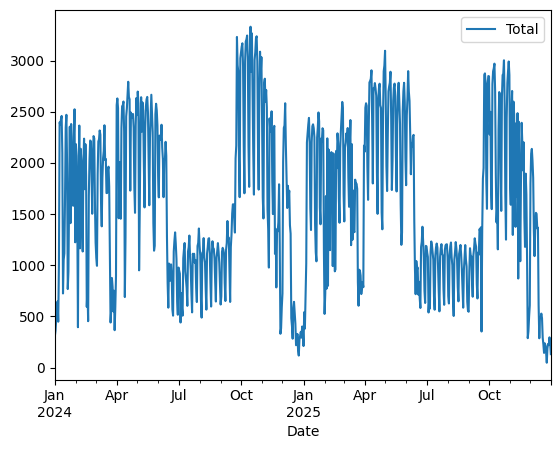

In [18]:
merged_data_direct[[
    # "In",
    # "Out",
    "Total"
]].plot()

<Axes: xlabel='Date'>

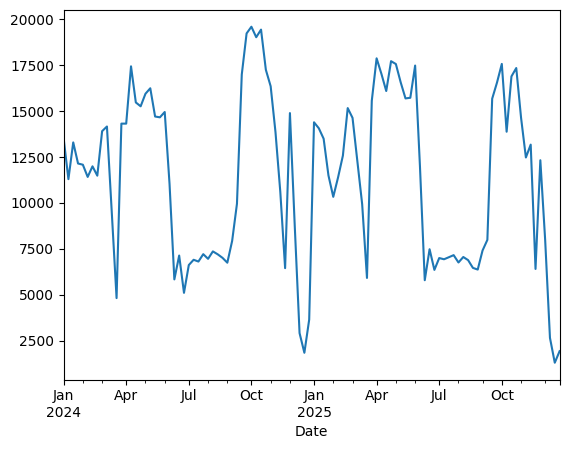

In [19]:
merged_data_direct_weekly["Total"].plot()